In [1]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_probability as tfp
tfd = tfp.distributions

from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

2025-12-16 13:33:49.663769: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-16 13:33:49.664342: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-16 13:33:49.739965: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-16 13:33:51.388571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
dtype = 'float32'

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# from uncertainty import *
# from utils import *

## Data

In [5]:
a = 0.5
b = 1.0

In [6]:
N = 500 # dataset size
m = 10  # subsample size
n = 500 # training size
J = 50  # number of subsamples

In [7]:
Xs = np.sort(np.random.uniform(low=0.0, high=a, size=N)).astype(dtype).reshape(-1,1)
new_Xs = np.sort(np.random.uniform(low=0.0, high=b, size=N)).astype(dtype).reshape(-1,1)

v = 0.1*Xs
new_v = 0.1*new_Xs

epsilon = np.array([np.random.normal(0, v[i]) for i in range(N)])
new_epsilon = np.array([np.random.normal(0, new_v[i]) for i in range(N)])

beta = 1.0
Ys = beta * Xs + epsilon.reshape(-1,1)
new_Ys = beta * new_Xs + new_epsilon.reshape(-1,1)

In [8]:
idx = np.random.choice(N, N, replace=False)
Xs = Xs[idx]
Ys = Ys[idx]
v = v[idx]

idx = np.random.choice(N, N, replace=False)
new_Xs = new_Xs[idx]
new_Ys = new_Ys[idx]
new_v = new_v[idx]

In [9]:
d = Xs.shape[1] # data dimension
d

1

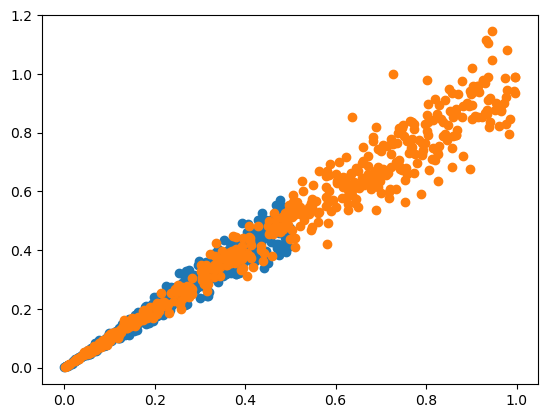

In [10]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.show()

In [11]:
ml_Ys_model = sm.OLS(Ys, Xs).fit()
ml_Ys = ml_Ys_model.predict(Xs)
ml_new_Ys_model = sm.OLS(new_Ys, new_Xs).fit()
ml_new_Ys = ml_new_Ys_model.predict(new_Xs)

In [12]:
plot_n = 200

In [13]:
# Prepare data for plot

new_Xs_plot = new_Xs[:plot_n].flatten()
new_Ys_plot = new_Ys[:plot_n].flatten()
ml_new_Ys_plot = ml_new_Ys[:plot_n].flatten()
std_new_Ys_plot = np.sqrt(new_v)[:plot_n].flatten()

sort_idx = np.argsort(new_Xs_plot)
new_Xs_sorted = new_Xs_plot[sort_idx]
new_Ys_sorted = new_Ys_plot[sort_idx]
ml_new_Ys_sorted = ml_new_Ys_plot[sort_idx]
std_new_Ys_plot_sorted = std_new_Ys_plot[sort_idx]


std_new_Ys_sorted = np.sqrt(std_new_Ys_plot_sorted)
lower_bound = ml_new_Ys_sorted - std_new_Ys_sorted
upper_bound = ml_new_Ys_sorted + std_new_Ys_sorted

#### Embedding $g_\xi$

In [14]:
representation_dim = 8

In [15]:
g = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=(d,), name='encoder_imodel_inputnput'),
                               tf.keras.layers.Dense(representation_dim, name='l1')])

2025-12-16 13:33:57.648173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#### Prediction model $f_\theta ∘ g_\xi$

In [16]:
pred_model = tf.keras.Sequential(list(g.layers) + [tf.keras.layers.Dense(1, use_bias=False)])

pred_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
pred_model.compile(optimizer=pred_optimizer, loss=tf.keras.losses.MeanSquaredError(), metrics=['accuracy'])

Train embedding parameters $\xi$ to maximize the likelihood of the training data $(X,Y)$

In [17]:
# train model on X, Y
history = pred_model.fit(Xs, Ys, epochs=100)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 0.1560   
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0913 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0517 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0326 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0245 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0216 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0199 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0185 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0173 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0160 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 0.0147 
Epoch 

In [18]:
vanilla_predictions = np.array(pred_model(new_Xs)).flatten()

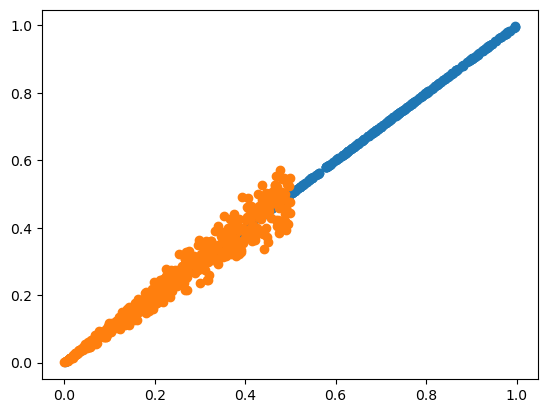

In [19]:
plt.scatter(new_Xs, vanilla_predictions)
plt.scatter(Xs, Ys)
plt.show()

In [20]:
# vanilla_nll, vanilla_rmse = regression_metrics(new_Ys, vanilla_predictions)
# print("NLL: %.4f, RMSE: %.4f" % (vanilla_nll, vanilla_rmse))

In [21]:
# # Calculate and sort true train densities
# p_Xs = tfp.distributions.Normal(loc=0.0, scale=1.0)
# plot_Xs_pdfs, plot_Xs = get_sorted(p_Xs.prob(Xs), Xs)

# # Calculate and sort true test densities
# p_new_Xs = p_Xs
# plot_new_Xs_pdfs, plot_new_Xs = get_sorted(p_new_Xs.prob(new_Xs), new_Xs)
# plot_predictions, _ = get_sorted(vanilla_predictions, new_Xs)
# plot_new_Ys, _ = get_sorted(new_Ys, new_Xs)

### VIDS

Define encoder $h_\gamma$

In [22]:
#############################################
# Encoder
#############################################

In [23]:
gXstar_inputs = tf.keras.Input(shape=(8,), name="gXstar_input")
gX_summary_input = tf.keras.Input(shape=(8,), name="gX_summary_input")
combined = tf.keras.layers.Concatenate()([gXstar_inputs, gX_summary_input])
gamma_layer = tf.keras.layers.Dense(64 * representation_dim, activation="relu")(combined)
gamma_layer = tf.keras.layers.Dense(32 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(16 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(8 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(4 * representation_dim, activation="relu")(gamma_layer)
gamma = tf.keras.layers.Dense(2 * representation_dim)(gamma_layer)

h = tf.keras.Model(inputs=[gXstar_inputs, gX_summary_input], outputs=gamma)

Train the encoder $h_\gamma$

In [24]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)

In [25]:
def log_normal_pdf(x, mu, sigma, eps=1e-8):
    """
    Computes the log probability density of a Normal distribution for each sample,
    summing over the last dimension.
    """
    log2pi = tf.math.log(2.0 * np.pi)
    return -0.5 * tf.reduce_sum(
        log2pi + 2 * tf.math.log(sigma + eps) + tf.square(x - mu) / (tf.square(sigma) + eps),
        axis=-1
    )

def log_likelihood_binary(logits, y):
    """
    Computes the log likelihood for binary classification.
    logits: shape [batch, 1]
    y: tensor of shape [batch] with values 0 or 1.

    Returns a tensor of shape [batch].
    """
    p = tf.sigmoid(logits)
    return tf.squeeze(y * tf.math.log(p + 1e-8) + (1 - y) * tf.math.log(1 - p + 1e-8), axis=-1)

def log_likelihood_multiclass(logits, y, num_classes):
    """
    Computes the log likelihood for multi-class classification.
    logits: shape [batch, num_classes]
    y: tensor of shape [batch] with integer labels or [batch, 1] (sparse labels).
    num_classes: total number of classes.
    
    Returns a tensor of shape [batch].
    """
    # Convert sparse labels to one-hot.
    y_one_hot = tf.one_hot(tf.reshape(y, [-1]), depth=num_classes)
    return -tf.nn.softmax_cross_entropy_with_logits(labels=y_one_hot, logits=logits)

def log_likelihood_regression(preds, y, sigma=1.0):
    """
    Computes the log likelihood for regression assuming a Gaussian likelihood.
    preds: shape [batch, 1]
    y: shape [batch, 1]
    sigma: fixed noise level (default 1.0)

    Returns a tensor of shape [batch].
    """
    return -0.5 * tf.math.log(2 * np.pi * sigma**2) - 0.5 * tf.square((y - preds)/sigma)

def integrated_log_likelihood_classification(logits, binary=True):
    """
    Computes a per-sample integrated log likelihood for classification.
    For binary classification it returns:
         p*log(p) + (1-p)*log(1-p)
    For multi-class, it returns sum_c [p(c) * log(p(c))].
    (This is essentially the negative entropy.)

    logits: if binary, shape [batch, 1]; if multiclass, shape [batch, num_classes]
    Returns a tensor of shape [batch].
    """
    if binary:
        p = tf.sigmoid(logits)
        p0 = 1 - p
        return tf.squeeze(p * tf.math.log(p + 1e-8) + p0 * tf.math.log(p0 + 1e-8), axis=-1)
    else:
        p = tf.nn.softmax(logits)
        return tf.reduce_sum(p * tf.math.log(p + 1e-8), axis=-1)

def integrated_log_likelihood_regression(preds, y_min, y_max, num_mc_samples=10):
    """
    Approximates the integrated (marginalized) log likelihood for regression by Monte Carlo.

    preds: tensor of predictions, shape [batch, 1]
    y_min, y_max: scalars defining the integration range.

    Returns a tensor of shape [batch].
    """
    R = num_mc_samples
    y_samples = tf.random.uniform(shape=[R], minval=y_min, maxval=y_max, dtype=preds.dtype)
    pred_expanded = tf.expand_dims(preds, axis=0)         
    y_samples_expanded = tf.reshape(y_samples, [R, 1, 1])    
    ll = -0.5 * tf.math.log(2 * np.pi) - 0.5 * tf.square(y_samples_expanded - pred_expanded)
    ll = tf.squeeze(ll, axis=-1)  
    integrated_ll = tf.reduce_mean(ll, axis=0)  
    return integrated_ll


def normalize_integrated_ll(v):
    """
    Normalizes a vector of integrated log likelihood values.

    Given v = [L(θ₁), L(θ₂), ..., L(θ_N)],
    we approximate the partition function Z as:
         Z ≈ mean(exp(v))
    and return v_norm = v - log(Z).
    """
    Z = tf.reduce_mean(tf.exp(v))
    return v - tf.math.log(Z + 1e-8)


def splits_fn(Xs, Ys, K, m, n):
  splits = []
  for k in range(K):
    N = len(Xs)
    fake_test_idx = np.random.choice(N, m, replace=True)
    fake_train_ids = np.random.choice(N, n, replace=True)
    splits.append([Xs[fake_train_ids], Ys[fake_train_ids], Xs[fake_test_idx], Ys[fake_test_idx]])
  return splits

def get_phi(h, gX, gXstar):

    # Compute training summary.
    gX_mean = tf.reduce_mean(gX, axis=0, keepdims=True)  # shape: [1, d]
    gX_mean_tiled = tf.tile(gX_mean, [tf.shape(gXstar)[0], 1])  # shape: [n, d]

    phi = h([gXstar, gX_mean_tiled])
    mu, sigma = tf.split(phi, num_or_size_splits=2, axis=-1)
    sigma = tf.nn.softplus(sigma) + 1e-6

    return mu, sigma

def train_posterior(Xs, Ys, g, h, optimizer, J, m, n, K=10, tau=1.0, lambda_val=1.0,
                    classification=True, binary=True, num_classes=None,
                    num_mc_samples=10, dtype='float32'):
    """
    Trains the posterior network h. In this version, we compute proper log probabilities
    (rather than losses) for the observed likelihood, and we combine them with a normalized
    integrated likelihood (acting as a prior).

    Returns the updated model h and a history list.
    """
    history = []

    if not classification:
        Ys_tensor = tf.cast(tf.convert_to_tensor(Ys), dtype)
        y_min = tf.reduce_min(Ys_tensor)
        y_max = tf.reduce_max(Ys_tensor)

    if classification and (not binary):
        if num_classes is None:
            raise ValueError("For multi-class classification, num_classes must be provided.")

    mse_train_print = None
    mse_test_print = None

    for k in tqdm(range(K)):
        splits = splits_fn(Xs, Ys, J, m, n)
        split_losses = []

        observed_train_ll_last = None
        observed_test_ll_last = None
        train_preds_last = None
        test_preds_last = None
        tmp_Y_last = None
        tmp_Ystar_last = None

        with tf.GradientTape() as tape:
            for j in range(J):
                tmp_X, tmp_Y, tmp_Xstar, tmp_Ystar = splits[j]

                # Compute embeddings
                gX = g(tmp_X)         
                gXstar = g(tmp_Xstar) 
                mu, sigma = get_phi(h, gX, gXstar)

                # Reparameterization
                eps = tf.random.normal(shape=tf.shape(mu), dtype=dtype)
                theta = mu + sigma * eps

                # Posterior log probability for θ (per sample from test split)
                posterior_log_probs = log_normal_pdf(theta, mu, sigma) 

                # Observed log likelihoods.
                if classification:
                    if binary:
                        theta_avg = tf.reduce_mean(theta, axis=0, keepdims=True)  
                        train_logits = tf.matmul(gX, theta_avg, transpose_b=True)  
                        obs_train_log_probs_vec = log_likelihood_binary(train_logits, tf.cast(tmp_Y, dtype))
                        observed_train_ll = tf.reduce_mean(obs_train_log_probs_vec)

                        test_logits_full = tf.matmul(gXstar, theta, transpose_b=True) 
                        test_logits = tf.linalg.diag_part(test_logits_full)  
                        obs_test_log_probs_vec = log_likelihood_binary(tf.expand_dims(test_logits, axis=-1),
                                                                       tf.cast(tmp_Ystar, dtype))
                        observed_test_ll = tf.reduce_mean(obs_test_log_probs_vec)

                        int_train_ll_vec = integrated_log_likelihood_classification(train_logits, binary=True)
                        int_train_ll_norm = normalize_integrated_ll(int_train_ll_vec)
                        integrated_train_ll = tf.reduce_mean(int_train_ll_norm)

                        test_logits_exp = tf.expand_dims(test_logits, axis=-1)
                        int_test_ll_vec = integrated_log_likelihood_classification(test_logits_exp, binary=True)
                        int_test_ll_norm = normalize_integrated_ll(int_test_ll_vec)
                        integrated_test_ll = tf.reduce_mean(int_test_ll_norm)

                    else:
                        d_rep = tf.shape(gXstar)[1]
                        theta_multi = tf.reshape(theta, [tf.shape(theta)[0], d_rep, num_classes])

                        theta_avg = tf.reduce_mean(theta, axis=0, keepdims=True)  
                        theta_avg_multi = tf.reshape(theta_avg, [d_rep, num_classes])
                        train_logits = tf.matmul(gX, theta_avg_multi) 
                        obs_train_log_probs_vec = log_likelihood_multiclass(train_logits, tmp_Y, num_classes)
                        observed_train_ll = tf.reduce_mean(obs_train_log_probs_vec)

                        test_logits = tf.einsum('nd, ndc -> nc', gXstar, theta_multi)  
                        obs_test_log_probs_vec = log_likelihood_multiclass(test_logits, tmp_Ystar, num_classes)
                        observed_test_ll = tf.reduce_mean(obs_test_log_probs_vec)

                        int_train_ll_vec = integrated_log_likelihood_classification(train_logits, binary=False)
                        int_train_ll_norm = normalize_integrated_ll(int_train_ll_vec)
                        integrated_train_ll = tf.reduce_mean(int_train_ll_norm)

                        int_test_ll_vec = integrated_log_likelihood_classification(test_logits, binary=False)
                        int_test_ll_norm = normalize_integrated_ll(int_test_ll_vec)
                        integrated_test_ll = tf.reduce_mean(int_test_ll_norm)

                else:
                    # Regression.
                    theta_avg = tf.reduce_mean(theta, axis=0, keepdims=True)  
                    train_preds = tf.matmul(gX, theta_avg, transpose_b=True)  
                    obs_train_log_probs_vec = log_likelihood_regression(train_preds, tmp_Y, sigma=1.0)
                    observed_train_ll = tf.reduce_mean(obs_train_log_probs_vec)

                    test_preds = tf.reduce_sum(gXstar * theta, axis=-1, keepdims=True)  
                    obs_test_log_probs_vec = log_likelihood_regression(test_preds, tmp_Ystar, sigma=1.0)
                    observed_test_ll = tf.reduce_mean(obs_test_log_probs_vec)

                    int_train_ll_vec = integrated_log_likelihood_regression(train_preds, y_min, y_max,
                                                                           num_mc_samples=num_mc_samples)
                    int_train_ll_norm = normalize_integrated_ll(int_train_ll_vec)
                    integrated_train_ll = tf.reduce_mean(int_train_ll_norm)

                    int_test_ll_vec = integrated_log_likelihood_regression(test_preds, y_min, y_max,
                                                                          num_mc_samples=num_mc_samples)
                    int_test_ll_norm = normalize_integrated_ll(int_test_ll_vec)
                    integrated_test_ll = tf.reduce_mean(int_test_ll_norm)

                    train_preds_last = train_preds
                    test_preds_last = test_preds
                    tmp_Y_last = tmp_Y
                    tmp_Ystar_last = tmp_Ystar

                observed_train_ll_last = observed_train_ll
                observed_test_ll_last = observed_test_ll

                # Log probability from normalized integrated likelihoods.
                prior_lp = integrated_train_ll + integrated_test_ll
                posterior_lp = tf.reduce_mean(posterior_log_probs)
                kl = posterior_lp - prior_lp

                observed_ll = observed_train_ll + observed_test_ll
                loss_j = -(observed_ll - lambda_val * kl)
                split_losses.append(loss_j)

            split_loss = tf.reduce_mean(tf.stack(split_losses))
            L_var = tf.math.reduce_variance(tf.stack(split_losses))
            final_loss = split_loss + tau * L_var

        grads = tape.gradient(final_loss, h.trainable_variables)
        optimizer.apply_gradients(zip(grads, h.trainable_variables))
        history.append(final_loss.numpy())

        if not classification:
            mse_train = tf.reduce_mean(tf.square(train_preds_last - tmp_Y_last))
            mse_test = tf.reduce_mean(tf.square(test_preds_last - tmp_Ystar_last))
            print("--- iteration %d, loss %.4f, split var: %.4f, train MSE: %.4f, test MSE: %.4f, KL: %.4f ---" %
                  (k, float(final_loss), float(L_var), float(mse_train), float(mse_test), float(kl)))
        else:
            train_loss_val = -observed_train_ll_last
            test_loss_val = -observed_test_ll_last
            print("--- iteration %d, loss %.4f, split var: %.4f, train loss: %.4f, test loss: %.4f, KL: %.4f ---" %
                  (k, float(final_loss), float(L_var), float(train_loss_val), float(test_loss_val), float(kl)))

    return h, history

In [26]:
h, losses = train_posterior(Xs, Ys, g, h, optimizer, J=30, m=20, n=500, K=30, tau=0.0, lambda_val=0.0005, classification=False)

  0%|          | 0/30 [00:00<?, ?it/s]

2025-12-16 13:34:10.356368: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


--- iteration 0, loss 1.9857, split var: 0.0026, train MSE: 0.1343, test MSE: 0.3096, KL: -8.4289 ---
--- iteration 1, loss 1.9459, split var: 0.0017, train MSE: 0.0641, test MSE: 0.1520, KL: -8.4177 ---
--- iteration 2, loss 1.8872, split var: 0.0010, train MSE: 0.0019, test MSE: 0.0874, KL: -7.8882 ---
--- iteration 3, loss 2.1455, split var: 0.0160, train MSE: 0.0695, test MSE: 0.1459, KL: -8.1237 ---
--- iteration 4, loss 1.8829, split var: 0.0003, train MSE: 0.0012, test MSE: 0.1032, KL: -8.1003 ---
--- iteration 5, loss 1.8868, split var: 0.0005, train MSE: 0.0222, test MSE: 0.0740, KL: -8.1781 ---
--- iteration 6, loss 1.9126, split var: 0.0008, train MSE: 0.0031, test MSE: 0.0872, KL: -7.7421 ---
--- iteration 7, loss 1.9105, split var: 0.0011, train MSE: 0.0243, test MSE: 0.1184, KL: -8.1525 ---
--- iteration 8, loss 1.9089, split var: 0.0009, train MSE: 0.0449, test MSE: 0.1262, KL: -7.7588 ---
--- iteration 9, loss 1.8972, split var: 0.0008, train MSE: 0.0312, test MSE: 0.04

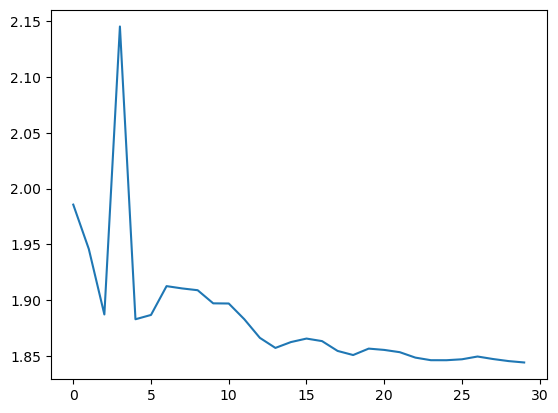

In [27]:
plt.plot(np.array(losses))
plt.show()

Learned posterior

In [28]:
use_sampling = True

In [29]:
# embeddings
gX = g(Xs)
gXstar = g(new_Xs)

posterior_mus, posterior_sigmas =  get_phi(h, gX, gXstar)

# evaluate uncertainty for x*
if use_sampling:
  n_samples_for_avg = 1000
  preds = []
  for i in tqdm(range(n_samples_for_avg)):
    # samples from learned posterior
    epsilon = tf.random.normal(shape=posterior_mus.shape)
    theta_samples =  posterior_mus + epsilon * posterior_sigmas
    # prediction with sampled theta
    fXstar = tf.reduce_sum(theta_samples * gXstar, axis=-1)
    preds.append(fXstar)
  variational_predictions = np.array(preds)
  variational_certainties = np.mean(preds, axis=0)
else:
  variational_predictions = tf.reduce_sum(posterior_mus * gXstar, axis=-1).numpy()
  variational_certainties = variational_predictions

  0%|          | 0/1000 [00:00<?, ?it/s]

In [30]:
posterior_var = np.var(variational_predictions, axis=0)
posterior_std = np.sqrt(posterior_var)

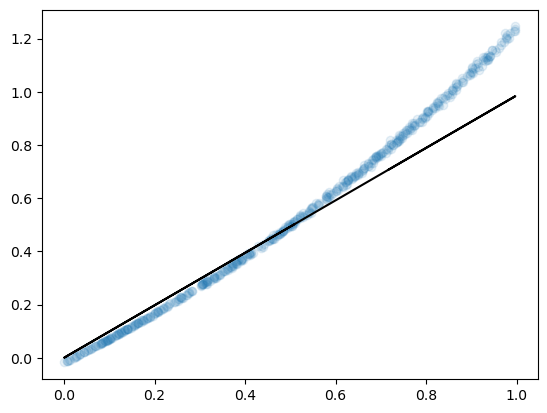

In [31]:
plt.scatter(new_Xs, variational_certainties, alpha=0.1)
plt.plot(new_Xs, ml_new_Ys, c='k')
plt.show()

In [32]:
# variational_nll, variational_rmse = regression_metrics(new_Ys, variational_certainties)
# print("NLL: %.4f, RMSE: %.4f" % (variational_nll, variational_rmse))